In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [4]:
df = pd.read_csv(r'd:\SMS6.csv', header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7
0,SMS,receive,22865,22865.1,date,321,SPAM,messages
1,SMS,receive,22865,22865,5/8/2014 11:09,321,SPAM,HEALTH is the greatest gift. A healthy outside...
2,SMS,receive,22865,22865,29/07/2014 12:19,321,SPAM,Do you know Ebola kills up to 90% of infected ...
3,SMS,receive,22865,22865,10/7/2014 11:16,321,SPAM,Enjoy latest films from all cinemas on your ph...
4,SMS,receive,MTN N,MTN N,8/8/2014 10:35,119,SPAM,Get the new MTN Android Smartphones for as low...


In [6]:
labels = df[6].values
messages = df[7].values

valid_col = [(l, m) for l, m in zip(labels, messages)    
             if l in ('HAM', 'SPAM') and isinstance(m, str)] # filter out invalid rows

# quick way to unzip the list of tuples into separate lists
labels, messages = zip(*valid_col)

In [7]:
len(labels), len(messages)

(1082, 1082)

In [87]:
STOP_WORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your',
    'yours', 'he', 'him', 'his', 'himself', 'she', 'her',
    'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with',
    'about', 'through', 'during', 'before', 'after', 'above',
    'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over',
    'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why',
    'how', 'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such',
    'no', 'nor', 'not', 'only', 'own', 'so', 'than', 'too', 'very', 's',
    't', 'can', 'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're',
    've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven',
    'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren',
    'wouldn', 'ing', 'ed'
}

def clean(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # Remove digits
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    text = ' '.join([word for word in text.split() if word not in STOP_WORDS and len(word) > 1]) # Remove stop words and single characters
    return text

messages_clean = [clean(t) for t in messages]

label = np.array([1 if l == 'SPAM' else 0 for l in labels])


In [88]:
len(messages)

1082

In [89]:
len(messages_clean)

1082

## Build a vocabulary & feature matrix

Assign index to new word 

In [90]:
# Build vocabulary
num_count = {}
idx = 0
for msg in messages_clean: 	
    for word in msg.split():
        if word not in num_count:
            num_count[word] = idx # Assign index to new word
            idx += 1 	# Increment index for new word

MIN_FREQ = 2
vocab = {}
idx = 0
for word, count in num_count.items():
    if count >= MIN_FREQ:
        vocab[word] = idx
        idx += 1
        
(vocab), len(vocab)

({'greatest': 0,
  'gift': 1,
  'healthy': 2,
  'outside': 3,
  'starts': 4,
  'inside': 5,
  'get': 6,
  'daily': 7,
  'tips': 8,
  'preventable': 9,
  'diseases': 10,
  'send': 11,
  'nweek': 12,
  'know': 13,
  'ebola': 14,
  'kills': 15,
  'infected': 16,
  'peoplethere': 17,
  'vaccination': 18,
  'cure': 19,
  'virus': 20,
  'enjoy': 21,
  'latest': 22,
  'films': 23,
  'cinemas': 24,
  'phone': 25,
  'movie': 26,
  'alerts': 27,
  'delivered': 28,
  'weekly': 29,
  'new': 30,
  'mtn': 31,
  'android': 32,
  'smartphones': 33,
  'low': 34,
  'music': 35,
  'food': 36,
  'soul': 37,
  'amin': 38,
  'dammy': 39,
  'krane': 40,
  'yello': 41,
  'fast': 42,
  'stream': 43,
  'video': 44,
  'oya': 45,
  'ladies': 46,
  'mins': 47,
  'voice': 48,
  'calls': 49,
  'yelloget': 50,
  'african': 51,
  'hit': 52,
  'tracks': 53,
  'hottest': 54,
  'app': 55,
  'loose': 56,
  'belly': 57,
  'fat': 58,
  'days': 59,
  'diet': 60,
  'subscribe': 61,
  'fastest': 62,
  'way': 63,
  'lose': 64,


## Feature matrix  using TF_ IDF 

In [91]:
# TF-IDF Feature Matrix (better than raw counts)
# TF  = term frequency = count of word in doc / total words in doc
# IDF = inverse document frequency = log(total docs / docs containing word)

# Step 1: Compute document frequency (how many messages contain each word)
doc_freq = np.zeros(len(vocab))
for msg in messages_clean:
    seen = set()
    for word in msg.split():
        if word in vocab and word not in seen:
            doc_freq[vocab[word]] += 1
            seen.add(word)

# Step 2: Compute IDF
n_docs = len(messages_clean)
idf = np.log((n_docs + 1) / (doc_freq + 1)) + 1  # smoothed IDF

# Step 3: Build TF-IDF matrix
X = np.zeros((len(messages_clean), len(vocab)))

for i, msg in enumerate(messages_clean):
    words = msg.split()
    n_words = len(words) if len(words) > 0 else 1
    for word in words:
        if word in vocab:
            X[i, vocab[word]] += 1  # raw count
# TF = count / total words in message
    X[i] = (X[i] / n_words) * idf  # TF * IDF

y = label.reshape(-1, 1)

print(f"Feature matrix shape: {X.shape}")
print(f"Spam ratio: {y.mean():.2%}")

Feature matrix shape: (1082, 2044)
Spam ratio: 35.03%


## Feature matrix - convert text to numbers by counting words 

- Using bag of word
- X[i, vocab[word]] += 1

In [92]:
# # to check how often each word appears in each message and create a feature matrix
# X = np.zeros((len(messages_clean), len(vocab)), dtype=int) 

# for i, msg in enumerate(messages_clean):
# 	for word in msg.split():
# 		if word in vocab:
# 			X[i, vocab[word]] += 1
# y = label.reshape(-1, 1)

# X, y

In [93]:
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

# Z features (important for logistic regression)
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-8  # add small value to avoid division by zero
	
X_train = (X_train - train_mean) / train_std
X_test  = (X_test - train_mean) / train_std  # use train mean and std  on test set to avoid data leakage

print(f"train: {X_train.shape}, test: {X_test.shape}")


train: (865, 2044), test: (217, 2044)


# Regularization is included 

In [97]:
# Sigmoid function
def sigmoid(z):
    z = np.clip(z, -500, 500)  # prevent overflow
    return 1 / (1 + np.exp(-z))

# Cost function (Binary Cross Entropy) with L2 regularization
def cost_function(X, y, w, b, reg_lambda=0.01):
    m = len(y)
    z = X @ w + b
    h = sigmoid(z)
    h = np.clip(h, 1e-8, 1 - 1e-8)  # avoid log(0)
    cost = -(1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    reg = (reg_lambda / (2 * m)) * np.sum(w**2)  # L2 regularization
    cost += reg	
    return cost

# Gradient Descent with L2 regularization
def gradient_descent(X, y, w, b, alpha, n_iter, reg_lambda=0.01):
    m = len(y)
    cost_history = []
    train_acc_history = []

    for i in range(n_iter):
        z = X @ w + b
        h = sigmoid(z)

        # Gradients
        dw = (1/m) * (X.T @ (h - y)) + (reg_lambda / m) * w  # L2 regularization gradient
        db = (1/m) * np.sum(h - y)

        # Update weights
        w = w - alpha * dw
        b = b - alpha * db

        # Track cost
        cost = cost_function(X, y, w, b, reg_lambda)
        cost_history.append(cost)
        
        preds = (sigmoid(X @ w + b) >= 0.5).astype(int)
        train_acc_history.append(np.mean(preds == y))

        if i % 100 == 0:
            print(f"iter {i}: Cost = {cost:.4f}")

    return w, b, cost_history, train_acc_history

# Initialize weights
n_features = X_train.shape[1]
w = np.zeros((n_features, 1))
b = 0

# Train
alpha = 0.5
n_iter = 5000
reg_lambda = 0.01

w, b, cost_history, train_acc_history = gradient_descent(X_train, y_train, w, b, alpha, n_iter, reg_lambda)

iter 0: Cost = 0.3820
iter 100: Cost = 0.0752
iter 200: Cost = 0.0696
iter 300: Cost = 0.0679
iter 400: Cost = 0.0670
iter 500: Cost = 0.0665
iter 600: Cost = 0.0662
iter 700: Cost = 0.0660
iter 800: Cost = 0.0658
iter 900: Cost = 0.0657
iter 1000: Cost = 0.0656
iter 1100: Cost = 0.0655
iter 1200: Cost = 0.0654
iter 1300: Cost = 0.0654
iter 1400: Cost = 0.0653
iter 1500: Cost = 0.0653
iter 1600: Cost = 0.0652
iter 1700: Cost = 0.0652
iter 1800: Cost = 0.0652
iter 1900: Cost = 0.0651
iter 2000: Cost = 0.0651
iter 2100: Cost = 0.0651
iter 2200: Cost = 0.0651
iter 2300: Cost = 0.0650
iter 2400: Cost = 0.0650
iter 2500: Cost = 0.0650
iter 2600: Cost = 0.0650
iter 2700: Cost = 0.0650
iter 2800: Cost = 0.0650
iter 2900: Cost = 0.0650
iter 3000: Cost = 0.0650
iter 3100: Cost = 0.0649
iter 3200: Cost = 0.0649
iter 3300: Cost = 0.0649
iter 3400: Cost = 0.0649
iter 3500: Cost = 0.0649
iter 3600: Cost = 0.0649
iter 3700: Cost = 0.0649
iter 3800: Cost = 0.0649
iter 3900: Cost = 0.0649
iter 4000: C

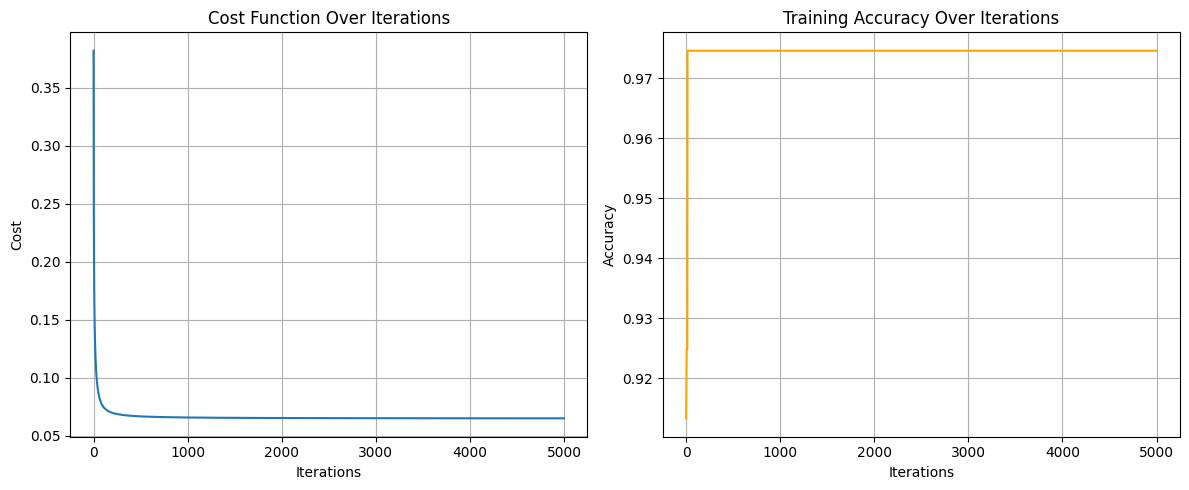

In [98]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(cost_history)
axes[0].set_title('Cost Function Over Iterations')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Cost')
axes[0].grid(True)

axes[1].plot(train_acc_history, c='orange')
axes[1].set_title('Training Accuracy Over Iterations')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [99]:
# Predictions
def predict(X, w, b, threshold=0.5):
    z = X @ w + b
    h = sigmoid(z)
    return (h >= threshold).astype(int), h


def evaluate(y_true, y_pred, set_name="Test"):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    
    print(f"\n{'='*40}")
    print(f"  {set_name} Set Results")
    print(f"{'='*40}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"              Predicted")
    print(f"              SPAM  HAM")
    print(f"  Actual SPAM  {tp:<5} {fn}")
    print(f"  Actual HAM   {fp:<5} {tn}")
    
    return accuracy, precision, recall, f1

# Train evaluation
y_pred_train, y_prob_train = predict(X_train, w, b)
train_acc, train_prec, train_rec, train_f1 = evaluate(y_train, y_pred_train, "Train")

# Test evaluation
y_pred_test, y_prob_test = predict(X_test, w, b)
test_acc, test_prec, test_rec, test_f1 = evaluate(y_test, y_pred_test, "Test")

print(f"\nAccuracy: {test_acc:.4f}")
print(f"\nPrecision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 Score:  {test_f1:.4f}")


  Train Set Results
  Accuracy:  0.9746
  Precision: 0.9550
  Recall:    0.9738
  F1 Score:  0.9643

  Confusion Matrix:
              Predicted
              SPAM  HAM
  Actual SPAM  297   8
  Actual HAM   14    546

  Test Set Results
  Accuracy:  0.8940
  Precision: 0.8072
  Recall:    0.9054
  F1 Score:  0.8535

  Confusion Matrix:
              Predicted
              SPAM  HAM
  Actual SPAM  67    7
  Actual HAM   16    127

Accuracy: 0.8940

Precision: 0.8072
Recall:    0.9054
F1 Score:  0.8535


In [100]:
def predict_spam(text):
    cleaned = clean(text)
    x = np.zeros((1, len(vocab)))
    for word in cleaned.split():
        if word in vocab:
            x[0, vocab[word]] += 1
    n_words = max(len(cleaned.split()), 1)
    x = (x / n_words) * idf # apply same TF-IDF transformation as training data
    x = (x - train_mean) / train_std  # normalize using training mean and std
    prob = sigmoid(x @ w + b)[0, 0]
    return f'{"SPAM" if prob >= 0.5 else "HAM"} (confidence: {prob:.4f})'

print(predict_spam('Congratulations you won a free prize click now'))
print(predict_spam('Hello, are we still meeting for lunch today?'))
print(predict_spam('Hurray, Congratulation!! you just won a bmw car prize'))
print(predict_spam('Loose belly fat in 7 days! Send DIET to 38261 at N10 only'))
print(predict_spam('Dear colleague, your presence at the department meeting is needed'))
print(predict_spam('Get FREE unlimited data now! Send DATA to 33388!'))

SPAM (confidence: 0.9435)
HAM (confidence: 0.0418)
SPAM (confidence: 0.9725)
SPAM (confidence: 1.0000)
HAM (confidence: 0.0245)
SPAM (confidence: 0.9980)


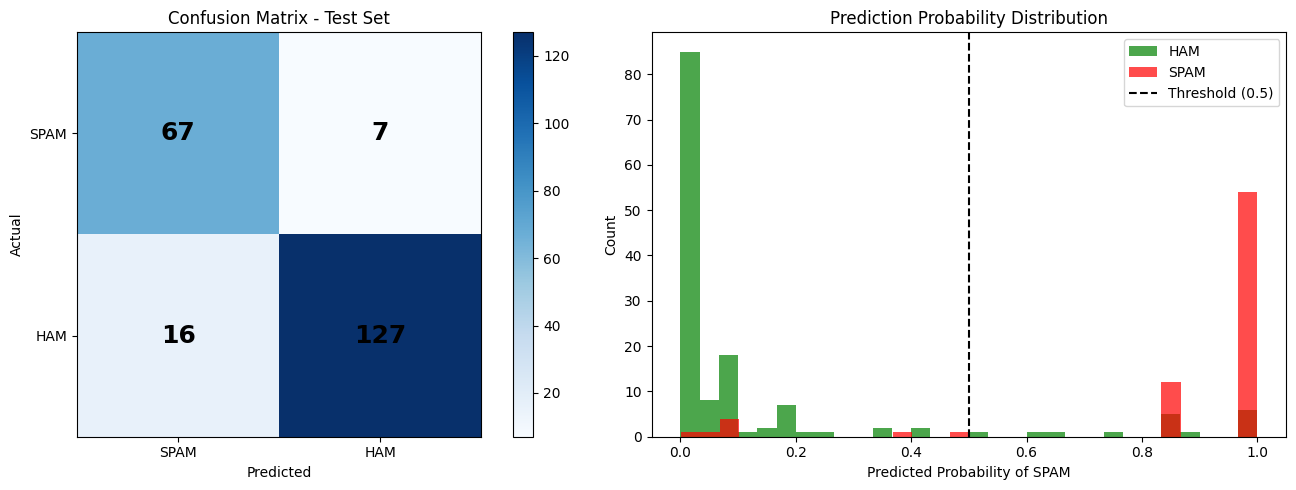

In [101]:
# Visualization — Confusion Matrix + Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
cm = np.array([
    [np.sum((y_pred_test == 1) & (y_test == 1)), np.sum((y_pred_test == 0) & (y_test == 1))],
    [np.sum((y_pred_test == 1) & (y_test == 0)), np.sum((y_pred_test == 0) & (y_test == 0))]
])

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['SPAM', 'HAM'])
axes[0].set_yticklabels(['SPAM', 'HAM'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - Test Set')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=18, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# Probability distribution
spam_probs = y_prob_test[y_test.flatten() == 1].flatten()
ham_probs = y_prob_test[y_test.flatten() == 0].flatten()
axes[1].hist(ham_probs, bins=30, alpha=0.7, label='HAM', color='green')
axes[1].hist(spam_probs, bins=30, alpha=0.7, label='SPAM', color='red')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1].set_title('Prediction Probability Distribution')
axes[1].set_xlabel('Predicted Probability of SPAM')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

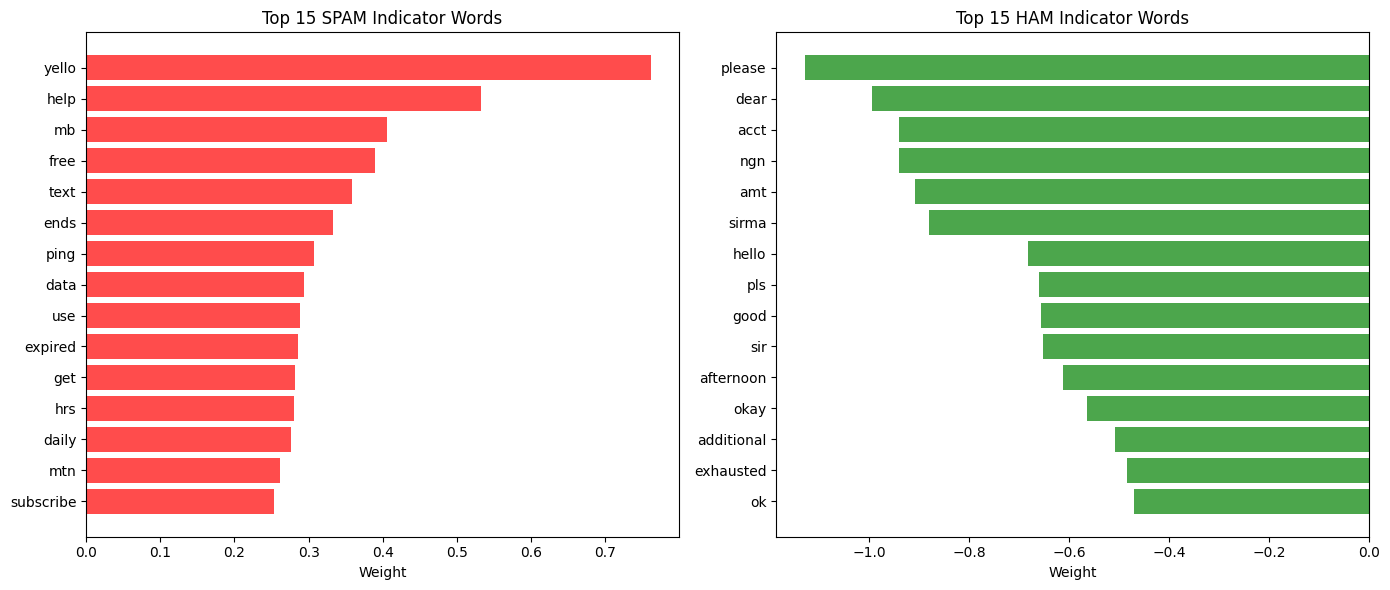

In [ ]:
# Top spam indicator words
top_n = 15
spam_word_indx = np.argsort(w.flatten())[::-1][:top_n] 
ham_word_indx = np.argsort(w.flatten())[:top_n]

idx_toword = {v: k for k, v in vocab.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

spam_words = [idx_toword[i] for i in spam_word_indx]
spam_weights = [w.flatten()[i] for i in spam_word_indx]
axes[0].barh(spam_words[::-1], spam_weights[::-1], color='red', alpha=0.7)
axes[0].set_title(f'Top {top_n} SPAM Indicator Words')
axes[0].set_xlabel('Weight')

ham_words = [idx_toword[i] for i in ham_word_indx]
ham_weights = [w.flatten()[i] for i in ham_word_indx]
axes[1].barh(ham_words[::-1], ham_weights[::-1], color='green', alpha=0.7)
axes[1].set_title(f'Top {top_n} HAM Indicator Words')
axes[1].set_xlabel('Weight')

plt.tight_layout()
plt.show()